In [40]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
from scipy.ndimage import uniform_filter1d
import pickle
from brokenaxes import brokenaxes
import matplotlib

#? 関数ファイルから必要な関数をインポート
from function_calculation import refractive, solve_T, calc_temp, plot_temp, cut_2d_array_by_threshold, approximation_cutoff_temp, approximation_cutoff_temp, nan_below_threshold_2d
from analyzers.class_temp_analyzer import make_temp_apr_dict

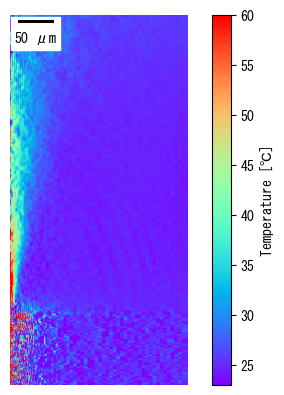

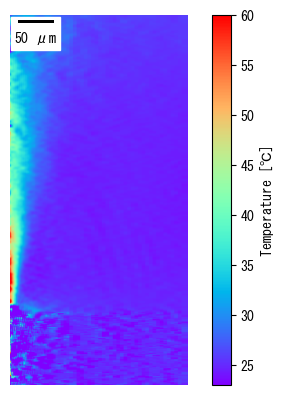

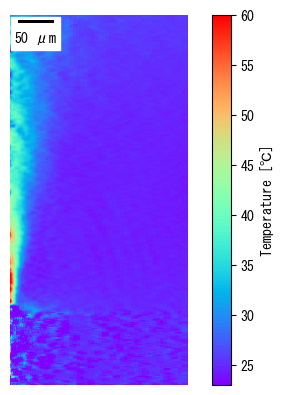

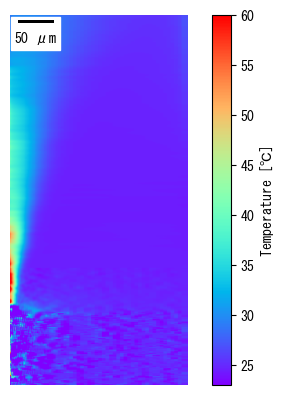

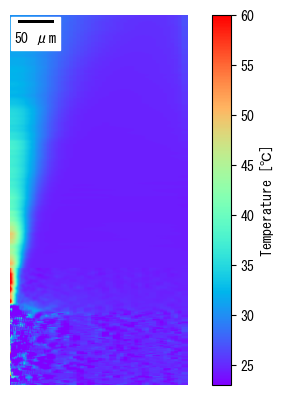

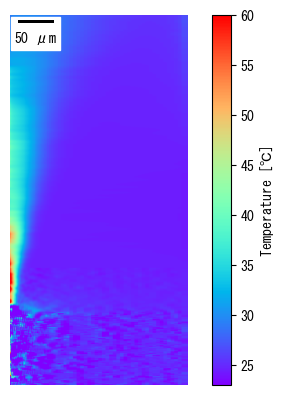

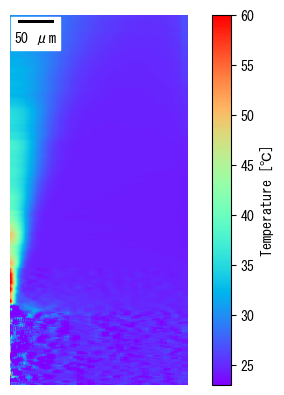

In [41]:
with open('temp_full_array_dict.pkl', 'rb') as f:
    temp_full_array_dict = pickle.load(f)

with open('temp_full_fig_dict.pkl', 'rb') as f:
    temp_full_fig_dict = pickle.load(f)

with open('x_axis_pix_half.pkl', 'rb') as f:
    x_axis_pix_half = pickle.load(f)

In [42]:
#* 温度の辞書から'_centered'を含むキーのみ抽出
temp_full_array_dict = { key: value for key, value in temp_full_array_dict.items() if '_centered' in key }

In [43]:
uniform_filter_size = 3
target = 24.5
threshold_cutoff = 5
h0 = 40
k = 600
T_room = 24.5
n_apr_pix = 700
min_points_required = 10


In [ ]:
#* 温度の辞書から'_centered'を含むキーのみ抽出
temp_full_array_dict = { key: value for key, value in temp_full_array_dict.items() if '_centered' in key }

#* scipyを使い、高さに対して移動平均を取る(unifrom処理)
#! size = 1 にしても、元の二次元配列と全く同じものが返るわけではない。
temp_full_array_uniform_dict = { key: uniform_filter1d(value.copy(), size=uniform_filter_size, axis=0, mode='nearest') for key, value in temp_full_array_dict.items() }

#* 温度分布cutoff処理
#! 温度がT_roomと一致する領域と基板領域にNaN埋めを実行。し二次元アレイの大きさは1024×1124を維持。
#? _uniform_する前の温度のcutoff辞書
# temp_full_array_cutoff_dict = { key: cut_2d_array_by_threshold(value.copy(), target, threshold_cutoff, h0, from_end=True) for key, value in temp_full_array_dict.items() }
temp_full_array_cutoff_dict = { key: nan_below_threshold_2d(value, T_room) for key, value in temp_full_array_dict.items() }

#? _uniform_した後の温度のcutoff辞書
# temp_full_array_uniform_cutoff_dict = { key: cut_2d_array_by_threshold(value.copy(), target, threshold_cutoff, h0, from_end=True) for key, value in temp_full_array_uniform_dict.items() }
temp_full_array_uniform_cutoff_dict = { key: nan_below_threshold_2d(value, T_room) for key, value in temp_full_array_uniform_dict.items() }

#* 近似処理
temp_full_array_cutoff_apr_dict, popt_full_dict, popt_init_full_dict, skipped_indices_full_dict = make_temp_apr_dict(temp_full_array_cutoff_dict,x_axis_pix_half, n_apr_pix, T_room, min_points_required)
temp_full_array_uniform_cutoff_apr_dict, popt_full_uniform_dict, popt_init_full_uniform_dict, skipped_indices_full_uniform_dict = make_temp_apr_dict(temp_full_array_cutoff_dict,x_axis_pix_half, n_apr_pix, T_room, min_points_required)

In [45]:
print(skipped_indices_full_dict)

{'offset_convolve_centered': array([ 92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 159, 160, 161,
       162, 163, 164, 165, 166, 167, 168, 169, 170, 192, 194, 209, 210,
       211, 212, 213, 214, 215, 216]), 'gaussian_plus_linear_centered': array([], dtype=float64), 'gaussian_plus_offset_centered': array([], dtype=float64)}


700 700


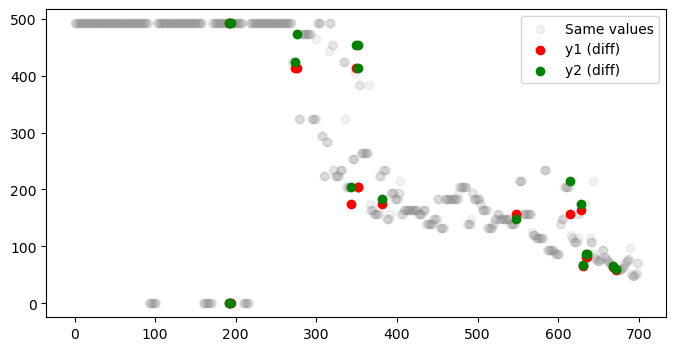

In [46]:
not_nan_counts_rows = np.sum(~np.isnan(temp_full_array_cutoff_dict['offset_convolve_centered'][:n_apr_pix]), axis=1)
not_nan_counts_uniform_rows = np.sum(~np.isnan(temp_full_array_uniform_cutoff_dict['offset_convolve_centered'][:n_apr_pix]), axis=1)
print(len(not_nan_counts_rows), len(not_nan_counts_uniform_rows))

same_mask = not_nan_counts_rows == not_nan_counts_uniform_rows
diff_mask = ~same_mask

fig = plt.figure(figsize=(8, 4))

# 同じ値の点（色1: 青）
plt.scatter(np.arange(n_apr_pix)[same_mask], not_nan_counts_rows[same_mask], color="gray", label="Same values", alpha=0.1)

# 異なる値（色2: 赤 y1側）
plt.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_rows[diff_mask], color="red", label="y1 (diff)")

# 異なる値（色3: 緑 y2側）
plt.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_uniform_rows[diff_mask], color="green", label="y2 (diff)")

plt.legend()
plt.show()

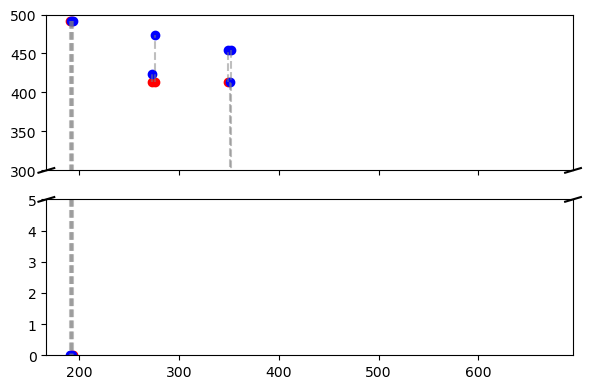

In [47]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6,4), gridspec_kw={'height_ratios': [1, 1]})

x =(np.arange(n_apr_pix)[diff_mask])
y_red = not_nan_counts_rows[diff_mask]
y_blue = not_nan_counts_uniform_rows[diff_mask]

# 上段: 高い範囲
ax1.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_rows[diff_mask], color="red")
ax1.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_uniform_rows[diff_mask],color="blue")
ax1.set_ylim(300, 500)

# 下段: 低い範囲
ax2.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_rows[diff_mask], color="red")
ax2.scatter(np.arange(n_apr_pix)[diff_mask], not_nan_counts_uniform_rows[diff_mask],color="blue")
ax2.set_ylim(0, 5)

# 同じx座標で赤点と青点を線で結ぶ
for xi, yr, yb in zip(x, y_red, y_blue):
    if (yr >= 390) and (yb >= 390):
        # 両方とも上段にある場合
        ax1.plot([xi, xi], [yr, yb], color="gray", linestyle="--", alpha=0.5)
    elif (yr <= 5) and (yb <= 5):
        # 両方とも下段にある場合
        ax2.plot([xi, xi], [yr, yb], color="gray", linestyle="--", alpha=0.5)
    else:
        # 上段と下段に分かれる場合
        # 上段側の点
        if yr >= 390:
            ax1.plot([xi, xi], [yr, ax1.get_ylim()[0]], color="gray", linestyle="--", alpha=0.5)
            ax2.plot([xi, xi], [ax2.get_ylim()[1], yb], color="gray", linestyle="--", alpha=0.5)
        elif yb >= 390:
            ax1.plot([xi, xi], [yb, ax1.get_ylim()[0]], color="gray", linestyle="--", alpha=0.5)
            ax2.plot([xi, xi], [ax2.get_ylim()[1], yr], color="gray", linestyle="--", alpha=0.5)




# 省略線を追加
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()

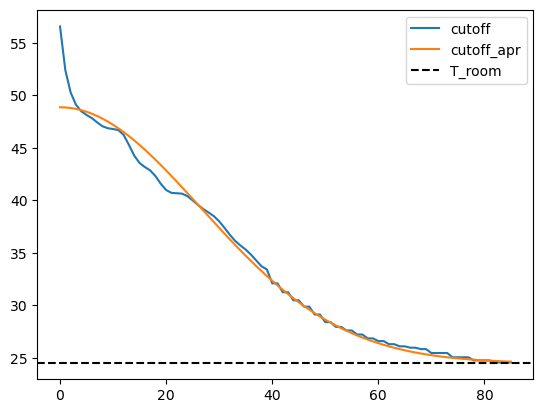

In [54]:
fig = plt.figure()
plt.plot(x_axis_pix_half, temp_full_array_cutoff_dict['offset_convolve_centered'][k], label='cutoff')
plt.plot(x_axis_pix_half, temp_full_array_cutoff_apr_dict['offset_convolve_centered'][k], label='cutoff_apr')
plt.axhline(y=T_room, color='black', linestyle='--', label='T_room')
plt.legend()
plt.show()

In [ ]:
for i in range(k-2, k+3):
    fig = plt.figure()
    plt.plot(x_axis_pix_half, temp_full_array_dict['offset_convolve_centered'][i], label='original')
    plt.plot(x_axis_pix_half, temp_full_array_cutoff_dict['offset_convolve_centered'][i], label='cutoff')
    plt.plot(x_axis_pix_half, temp_full_array_cutoff_apr_dict['offset_convolve_centered'][i], label='cutoff_apr')
    plt.axhline(y=T_room, color='black', linestyle='--', label='T_room')
    plt.legend()
    plt.show()

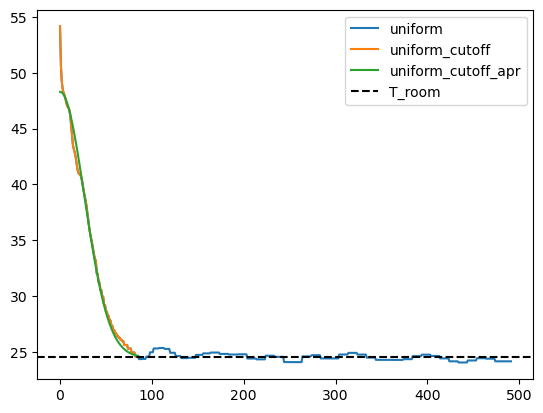

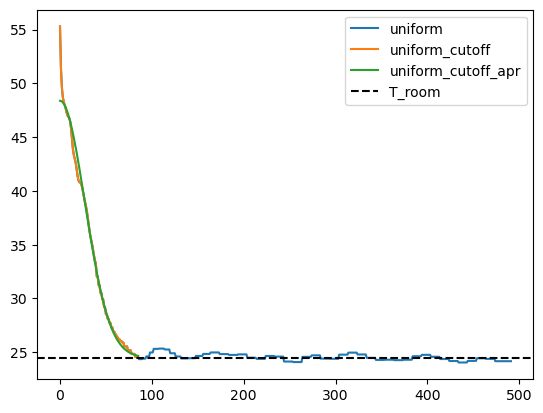

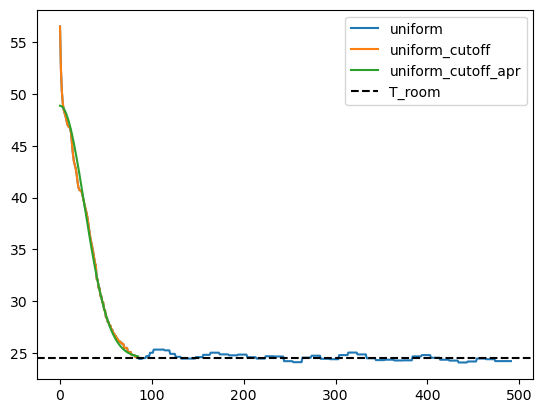

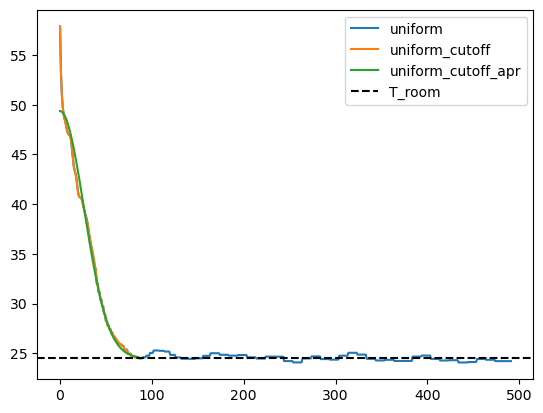

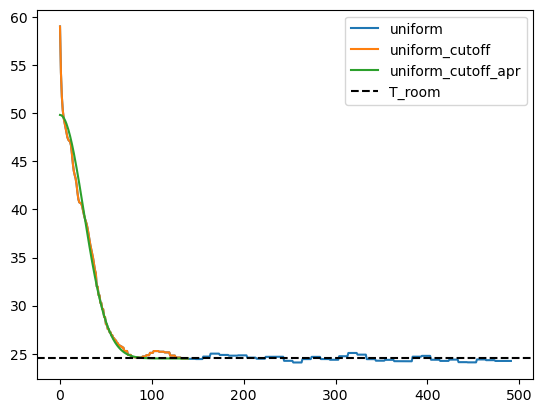

In [51]:
for i in range(k-2, k+3):
    fig = plt.figure()
    plt.plot(x_axis_pix_half, temp_full_array_uniform_dict['offset_convolve_centered'][i], label='uniform')
    plt.plot(x_axis_pix_half, temp_full_array_uniform_cutoff_dict['offset_convolve_centered'][i], label='uniform_cutoff')
    plt.plot(x_axis_pix_half, temp_full_array_uniform_cutoff_apr_dict['offset_convolve_centered'][i], label='uniform_cutoff_apr')
    plt.axhline(y=T_room, color='black', linestyle='--', label='T_room')
    plt.legend()
    plt.show()
    
    # print(uniform_array[i])